# Computing Vorticity from MPAS Data with UXarray

This notebook demonstrates how to:
1. Open an MPAS unstructured-grid NetCDF dataset with UXarray
2. Compute vorticity from the 10-meter wind components `u10` and `v10`
3. Visualize the result as a shaded polygon plot

**Dataset:** MPAS-Atmosphere 120 km mesh diagnostic output  
**Grid:** 40,962-cell quasi-uniform global mesh

In [1]:
import uxarray as ux
import numpy as np
import holoviews as hv

hv.extension("matplotlib")
print(f"UXarray version: {ux.__version__}")

UXarray version: 2026.2.1.dev4+g4279e41a6.d20260302


## 1. Load the MPAS Dataset

UXarray requires a **grid file** (topology: cell connectivity, coordinates) and a
**data file** (field variables on that mesh).  Pass both to `ux.open_dataset`.

In [2]:
grid_path = "/Users/Shared/JohnsData/MPAS/dymond_1_Falko/120km/x1.40962.grid.nc"
data_path = "/Users/Shared/JohnsData/MPAS/dymond_1_Falko/120km/diag.2016-08-20_00.00.00.nc"

uxds = ux.open_dataset(grid_path, data_path)
uxds

<xarray.UxDataset> Size: 16MB
Dimensions:             (time: 1, n_face: 40962, n_node: 81920)
Coordinates:
  * time                (time) datetime64[ns] 8B 2016-08-20
Dimensions without coordinates: n_face, n_node
Data variables: (12/90)
    xtime               (time) |S64 64B ...
    taux                (time, n_face) float32 164kB ...
    tauy                (time, n_face) float32 164kB ...
    olrtoa              (time, n_face) float32 164kB ...
    cldcvr              (time, n_face) float32 164kB ...
    vert_int_qv         (time, n_face) float32 164kB ...
    ...                  ...
    aclwupt             (time, n_face) float32 164kB ...
    aclwdnt             (time, n_face) float32 164kB ...
    aclwnett            (time, n_face) float32 164kB ...
    rainc               (time, n_face) float32 164kB ...
    rainnc              (time, n_face) float32 164kB ...
    zgrid               (n_face) float32 164kB ...

The dataset has:
- `n_face` – the 40,962 MPAS cells (faces in UXarray terminology)
- `n_node` – the 81,920 vertices
- A single time step at 2016-08-20

Inspect the underlying `Grid` object to confirm the mesh topology:

In [3]:
print(uxds.uxgrid)

<uxarray.Grid>
Original Grid Type: MPAS
Grid Dimensions:
  * n_node: 81920
  * n_edge: 122880
  * n_face: 40962
  * n_max_face_nodes: 10
  * n_max_face_edges: 10
  * n_max_face_faces: 10
  * n_max_node_faces: 3
  * n_max_node_edges: 3
  * two: 2
Grid Coordinates (Spherical):
  * node_lon: (81920,)
  * node_lat: (81920,)
  * edge_lon: (122880,)
  * edge_lat: (122880,)
  * face_lon: (40962,)
  * face_lat: (40962,)
Grid Coordinates (Cartesian):
  * node_x: (81920,)
  * node_y: (81920,)
  * node_z: (81920,)
  * edge_x: (122880,)
  * edge_y: (122880,)
  * edge_z: (122880,)
  * face_x: (40962,)
  * face_y: (40962,)
  * face_z: (40962,)
Grid Connectivity Variables:
  * edge_face_connectivity: (122880, 2)
  * node_face_connectivity: (81920, 3)
  * edge_node_connectivity: (122880, 2)
  * node_edge_connectivity: (81920, 3)
  * face_face_connectivity: (40962, 10)
  * face_node_connectivity: (40962, 10)
  * face_edge_connectivity: (40962, 10)
Grid Descriptor Variables:
  * face_areas: (40962,)
  *

## 2. Extract the 10-Meter Wind Components

`u10` and `v10` are the zonal and meridional 10-meter winds (m/s), both
face-centered and shaped `(time, n_face)`.  UXarray's `curl` method requires
1-D arrays, so we select the single time step with `.isel(time=0)`.

In [4]:
u10 = uxds["u10"].isel(time=0)
v10 = uxds["v10"].isel(time=0)

print("u10:", u10)
print()
print("v10:", v10)

u10: <xarray.UxDataArray 'u10' (n_face: 40962)> Size: 164kB
[40962 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2016-08-20
Dimensions without coordinates: n_face
Attributes:
    units:      m s^{-1}
    long_name:  10-meter zonal wind

v10: <xarray.UxDataArray 'v10' (n_face: 40962)> Size: 164kB
[40962 values with dtype=float32]
Coordinates:
    time     datetime64[ns] 8B 2016-08-20
Dimensions without coordinates: n_face
Attributes:
    units:      m s^{-1}
    long_name:  10-meter meridional wind


Quick sanity check – look at the wind statistics:

In [5]:
print(f"u10  min={float(u10.min()):.2f}  max={float(u10.max()):.2f}  mean={float(u10.mean()):.2f} m/s")
print(f"v10  min={float(v10.min()):.2f}  max={float(v10.max()):.2f}  mean={float(v10.mean()):.2f} m/s")

u10  min=-19.38  max=25.38  mean=-0.29 m/s
v10  min=-22.96  max=18.80  mean=0.85 m/s


## 3. Compute Relative Vorticity

Relative vorticity is the vertical component of the curl of the horizontal
wind vector:

$$\zeta = \frac{\partial v}{\partial x} - \frac{\partial u}{\partial y}$$

UXarray computes this directly with `UxDataArray.curl()`.  Call it on the
zonal component and pass the meridional component as the argument:

In [6]:
vorticity = u10.curl(v10)
vorticity

<xarray.UxDataArray 'curl_u10_v10' (n_face: 40962)> Size: 328kB
array([-132.26314218, -106.4276891 ,  -80.35460038, ...,  443.93781023,
        534.98143513,  386.89729613], shape=(40962,))
Dimensions without coordinates: n_face
Attributes:
    long_name:    Curl of (u10, v10)
    units:        (m s^{-1})/m
    description:  Curl of vector field computed as ∂v/∂x - ∂u/∂y

In [7]:
print(f"Vorticity  min={float(vorticity.min()):.1f}  max={float(vorticity.max()):.1f}  "
      f"units={vorticity.attrs.get('units', 'unknown')}")

Vorticity  min=-4432.9  max=3155.1  units=(m s^{-1})/m


## 4. Plot the Vorticity Field

### 4a. Global view — polygon fill

`plot.polygons()` renders each MPAS cell as a shaded polygon.  We clip the
color range to ±100 s⁻¹ to suppress a few extreme boundary values and
highlight synoptic-scale circulation patterns.

:Image   [x,y]   (x_y curl_u10_v10)
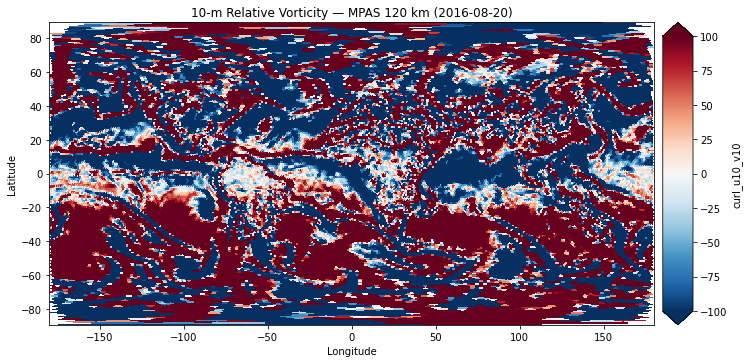

In [8]:
vorticity.plot.polygons(
    title="10-m Relative Vorticity — MPAS 120 km (2016-08-20)",
    cmap="RdBu_r",
    clim=(-100, 100),
    width=900,
    height=450,
)

### 4b. Comparison: U10, V10, and vorticity side-by-side

Plot the two wind components alongside the derived vorticity using UXarray's
polygon renderer with matplotlib as the backend.

:Layout
   .Image.I   :Image   [x,y]   (x_y u10)
   .Image.II  :Image   [x,y]   (x_y v10)
   .Image.III :Image   [x,y]   (x_y curl_u10_v10)
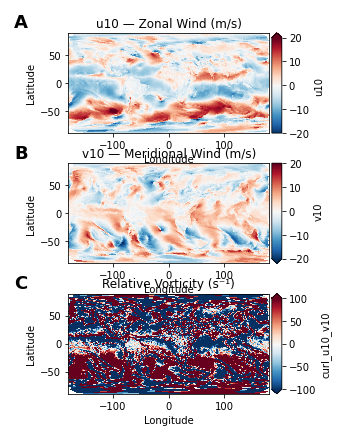

In [9]:
plot_kwargs = dict(width=600, height=300, backend="matplotlib")

p_u = u10.plot.polygons(
    title="u10 — Zonal Wind (m/s)",
    cmap="RdBu_r",
    clim=(-20, 20),
    **plot_kwargs,
)
p_v = v10.plot.polygons(
    title="v10 — Meridional Wind (m/s)",
    cmap="RdBu_r",
    clim=(-20, 20),
    **plot_kwargs,
)
p_vort = vorticity.plot.polygons(
    title="Relative Vorticity (s⁻¹)",
    cmap="RdBu_r",
    clim=(-100, 100),
    **plot_kwargs,
)

(p_u + p_v + p_vort).cols(1)

### 4c. Regional zoom — North Atlantic

Use UXarray's `subset.bounding_box` to extract the North Atlantic subdomain
and re-plot at higher detail.

:Image   [x,y]   (x_y curl_u10_v10)
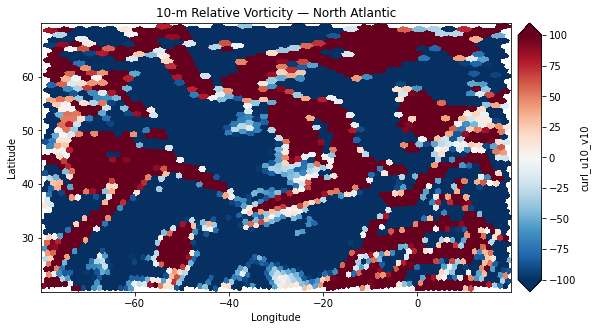

In [10]:
# Bounding box: lon [-80, 20], lat [20, 70]  (degrees)
vort_natl = vorticity.subset.bounding_box(
    lon_bounds=(-80, 20),
    lat_bounds=(20, 70),
)

vort_natl.plot.polygons(
    title="10-m Relative Vorticity — North Atlantic",
    cmap="RdBu_r",
    clim=(-100, 100),
    width=700,
    height=400,
)

## Summary

| Step | UXarray call |
|------|-------------|
| Open grid + data | `ux.open_dataset(grid_path, data_path)` |
| Select time step | `uxds["u10"].isel(time=0)` |
| Compute vorticity | `u10.curl(v10)` |
| Global polygon plot | `vorticity.plot.polygons(...)` |
| Regional subset | `vorticity.subset.bounding_box(...)` |

`UxDataArray.curl(other)` computes ∂v/∂x − ∂u/∂y using the finite-volume
gradient infrastructure built into UXarray, and returns a face-centered
`UxDataArray` with appropriate `units` and `long_name` metadata already set.